# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

## Classificação de Texto usando uma Rede Neural Recorrente (RNN)

Objetivo: apresentar um exemplo de uso de uma Rede Neural Recorrente para classificação de texto.

Você vai aprender a:
- Usar as bibliotecas de Redes Neurais Recorrentes
- Configurar uma arquitetura usando camadas LSTM biderecionais
- Treinar um modelo de PLN para classificação de sentimentos
- Avaliar o modelo treinado

Referências: <br>
O código do exemplo foi obtido de: <br>
https://www.tensorflow.org/text/tutorials/text_classification_rnn <br>
Documentação da API Keras para Camadas Recorrentes:<br>
https://keras.io/api/layers/recurrent_layers/<br>
https://www.tensorflow.org/guide/keras/working_with_rnns<br>

Versão: Fevereiro, 2024

### Pacotes

In [1]:
# Instala bibliotecas, se necessário
#!pip install tensorflow_datasets

In [1]:
import numpy as np
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

tfds.disable_progress_bar()

/home/marcos/Área de trabalho/Mestrado/2 - Segundo Semestre/Aplicações de Redes Neurais/neural-networks-course/2 - Redes Neurais para Processamento de Linguagem Natural/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-09-08 22:42:30.895542: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-08 22:42:31.312453: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-08 22:42:31.312658: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-08 22:42:31.315117: E te

### Função para plotar gráficos

In [2]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

### Dataset

IMDB - dataset de revisão de filmes, rotulado para classificação binária: sentimento positivo ou negativo.

In [3]:
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

train_dataset.element_spec

2026-09-08 22:42:54.757096: W tensorflow/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dataset imdb_reviews downloaded and prepared to /home/marcos/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


(TensorSpec(shape=(), dtype=tf.string, name=None),
 TensorSpec(shape=(), dtype=tf.int64, name=None))

In [4]:
# Retorna uma amostra do dataset de treino. Par: texto, rótulo
for example, label in train_dataset.take(1):
  print('text: ', example.numpy())
  print('label: ', label.numpy())

text:  b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."
label:  0


2026-09-08 22:46:38.094687: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Embaralha os dados de treinamento <br>
Cria batches (lotes) para os pares texto, rótulo

In [5]:
BUFFER_SIZE = 10000
BATCH_SIZE = 64

In [6]:
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
for example, label in train_dataset.take(1):
  print('texts: ', example.numpy()[:3])
  print()
  print('labels: ', label.numpy()[:3])

texts:  [b"The fluttering of butterfly wings in the Atlantic can unleash a hurricane in the Pacific. According to this theory (somehow related to the Chaos Theory, I'm not sure exactly how), every action, no matter how small or insignificant, will start a chain reaction that can lead to big events. This small jewel of a film shows us a series of seemingly-unrelated characters, most of them in Paris, whose actions will affect each others' lives. (The six-degrees-of-separation theory can be applied as well.) Each story is a facet of the jewel that is this film. The acting is finely-tuned and nuanced (Audrey Tautou is luminous), the stories mesh plausibly, the humor is just right, and the viewer leaves the theatre nodding in agreement."
 b'I love horror movies. I can even appreciate most cheese (face it, 9 out of 10 horror films these days ARE cheese), but this was just ridiculous. Terrible acting, terrible writing, completely hollow and unbelievable characters (no Meisner actors here!) a

2026-09-08 22:46:46.216192: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Codificação (Encoder) do Texto

O texto bruto carregado pelo tfds necessita ser processado antes que ele possa ser usado em um modelo. A forma mais simples de processar o texto para treinamento é usar a camada *TextVectorization*. Essa camada tem muitas capacidades, mas aqui usaremos o seu comportamento padrão.

Cria a camada e passa o texto do dataset para seu método *.adapt*.

In [8]:
VOCAB_SIZE = 1000
encoder = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE)
encoder.adapt(train_dataset.map(lambda text, label: text))

O método *.adapt* define o vocabulário da camada.<br>
Listamos abaixo os primeiros 20 tokens, ordenados por frequência, exceto os dois primeiros, que são o token de preenchimento (*padding*) e token desconhecido (*unknown*)

In [9]:
vocab = np.array(encoder.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i',
       'this', 'that', 'br', 'was', 'as', 'for', 'with', 'movie', 'but'],
      dtype='<U14')

Uma vez que o vocabulário é definido, a camada pode codificar o texto em índices. Os tensores de índices são preenchidos com zeros (*0-padded*) para a sequência mais longa no batch (a menos que você defina um valor fixo para *output_sequence_length*.

In [10]:
encoded_example = encoder(example)[:3].numpy()
encoded_example

array([[  2,   1,   5, ...,   0,   0,   0],
       [ 10, 116, 197, ...,   0,   0,   0],
       [  2, 177,   5, ...,   0,   0,   0]])

Com a configuração padrão, o processo não é completamente reversível. As principais razões são:
- O valor padrão para *preprocessing.TextVectorization* é "lower_and_strip_punctuation".
- O tamanho limitado do vocabulário e a falta de alternativa baseada em caracteres resultam em alguns tokens desconhecidos.

In [11]:
for n in range(3):
  print("Original: ", example[n].numpy())
  print("Round-trip: ", " ".join(vocab[encoded_example[n]]))
  print()

Original:  b"The fluttering of butterfly wings in the Atlantic can unleash a hurricane in the Pacific. According to this theory (somehow related to the Chaos Theory, I'm not sure exactly how), every action, no matter how small or insignificant, will start a chain reaction that can lead to big events. This small jewel of a film shows us a series of seemingly-unrelated characters, most of them in Paris, whose actions will affect each others' lives. (The six-degrees-of-separation theory can be applied as well.) Each story is a facet of the jewel that is this film. The acting is finely-tuned and nuanced (Audrey Tautou is luminous), the stories mesh plausibly, the humor is just right, and the viewer leaves the theatre nodding in agreement."
Round-trip:  the [UNK] of [UNK] [UNK] in the [UNK] can [UNK] a [UNK] in the [UNK] [UNK] to this [UNK] somehow [UNK] to the [UNK] [UNK] im not sure exactly how every action no matter how small or [UNK] will start a [UNK] [UNK] that can lead to big events 

### Modelo de Classificação

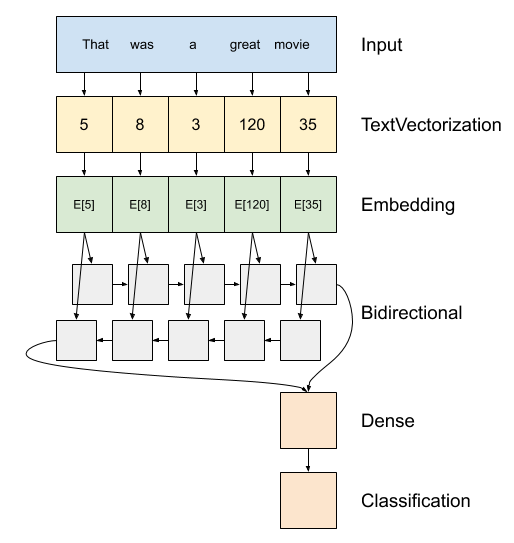

1. O modelo pode ser criado como um *tf.keras.Sequential*.
2. A primeira camada é o *encoder*, que converte o texto para uma sequência de índices de tokens.
3. Depois do *encoder* está a camada de *embedding*. Uma cada de *embedding* armazena um vetor por palavra. Quando chamada, ela converte as sequências de índices de palavras em sequências de vetores. Esses vetores são treináveis. Depois de treinados (com dados suficientes), palavras com significados similares frequentemente têm vetores similares. Esse esquema é mais eficiente do que a operação equivalente de se criar um vetor *one-hot encoded* por meio da camada *tf.keras.layers.Dense*.
4. A Rede Neural Recorrente (RNN) processa uma sequência de entrada por meio da iteração dos elementos. RNNs passam a saída de um passo de tempo (*timestep*) para sua entrada no próximo *timestep*. O *wrapper* *tf.keras.layers.Bidirectional* também pode ser usado com uma camada RNN. Isso propaga a entrada para frente e para trás na camada RNN e então concatena a saída final. Nós usamos aqui uma camada LSTM (Long Short-Term Memory).
   - A principal vantagem de uma RNN bidirecional é que o sinal desde o início da entrada não necessita ser processado em cada intervalo de tempo para afetar a saída.
   - A principal desvantagem de uma RNN bidirecional é que você não pode transmitir previsões com eficiência à medida que palavras são adicionadas ao final.
6. Depois que a RNN converte a sequência em um único vetor, as duas camadas densas fazem algum processamento final e convertem essa representação vetorial em um único logit como saída da classificação.

In [12]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(
        input_dim=len(encoder.get_vocabulary()),
        output_dim=64,
        # Use masking to handle the variable sequence lengths
        mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])

Compila o modelo Keras para configurar o processo de treinamento

In [13]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

### Treinamento do Modelo

In [15]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 297s 756ms/step - loss: 0.3163 - accuracy: 0.8638 - val_loss: 0.3310 - val_accuracy: 0.8589
Epoch 2/10


2026-09-08 23:24:23.157697: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 279s 714ms/step - loss: 0.3107 - accuracy: 0.8671 - val_loss: 0.3254 - val_accuracy: 0.8500
Epoch 3/10


2026-09-08 23:29:02.352276: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 266s 681ms/step - loss: 0.3081 - accuracy: 0.8680 - val_loss: 0.3246 - val_accuracy: 0.8521
Epoch 4/10


...

2026-09-08 23:56:26.233744: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 276s 706ms/step - loss: 0.2953 - accuracy: 0.8730 - val_loss: 0.3256 - val_accuracy: 0.8635
Epoch 10/10


2026-09-09 00:01:02.540689: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


391/391 [==============================] - 279s 712ms/step - loss: 0.2957 - accuracy: 0.8720 - val_loss: 0.3203 - val_accuracy: 0.8646


2026-09-09 00:05:41.074484: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


### Avaliação do Modelo no Conjunto de Dados de Teste

In [16]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 71s 181ms/step - loss: 0.3197 - accuracy: 0.8636
Test Loss: 0.31973230838775635
Test Accuracy: 0.8636400103569031


Plota gráficos de acurácia e perda

(0.0, 0.33277024924755094)

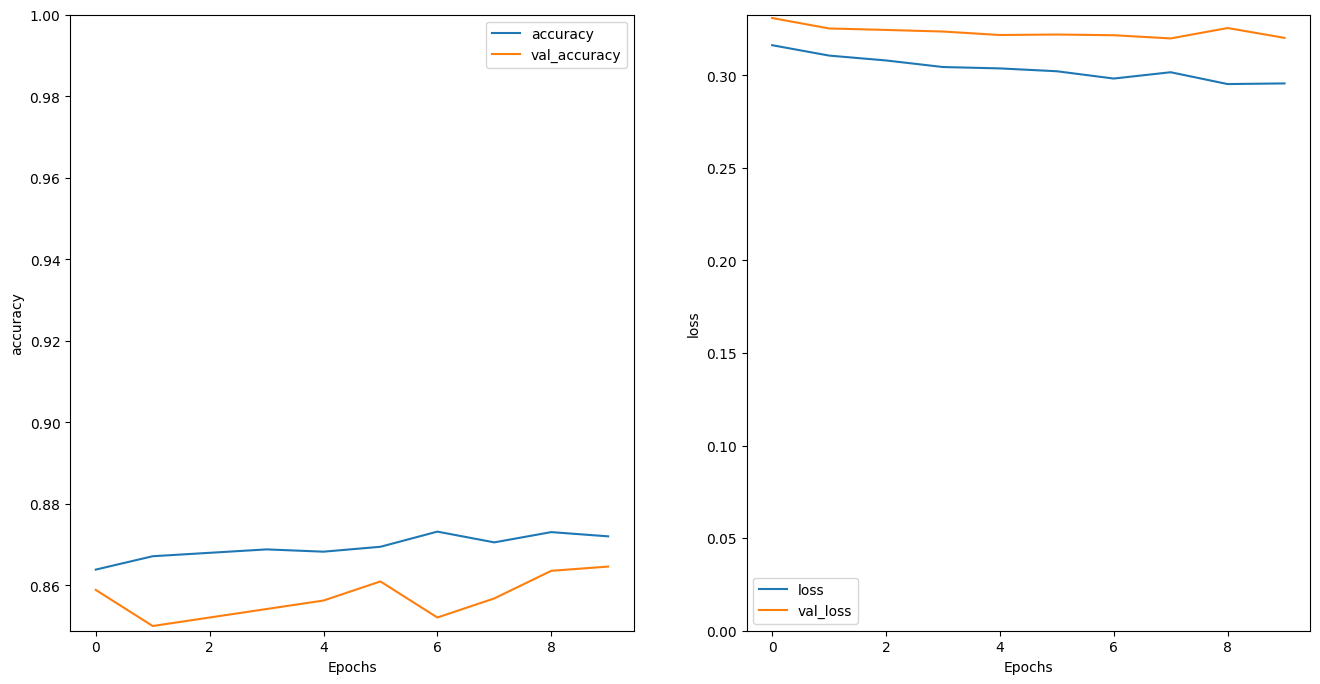

In [17]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

### Predição de uma Nova Sentença

Se a predição for >= 0.0, então ela é positiva, caso contrário, ela é negativa

In [18]:
sample_text = ('The movie was cool. The animation and the graphics '
               'were out of this world. I would recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 4s 4s/step
[[0.7792866]]


### Pilha de Camadas LSTM

Em uma arquitetura de Redes Neurais Recorrentes, várias camadas podem ser empilhadas para produzir o resultado final. Nesse caso, a saída de cada *timestep* é conectada na entrada do *timestep* da camada acima.

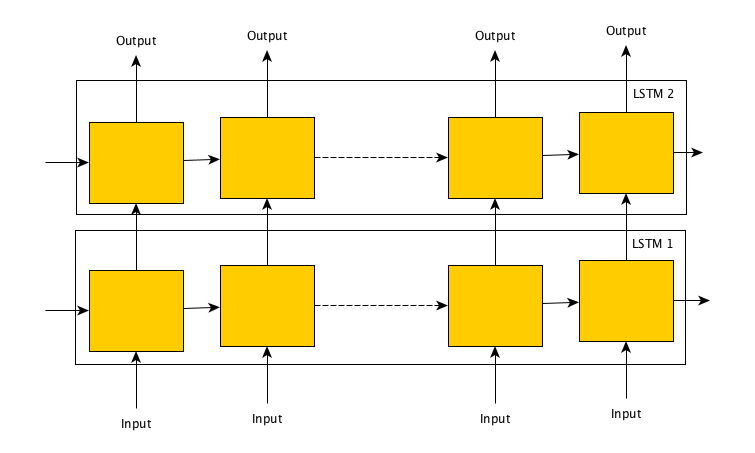

As camadas recorrentes Keras têm dois modos disponíveis que são controlados pelo argumento *return_sequences*:
- Se False, ele retorna somente a última saída para cada sequência de entrada (um tensor 2D na forma *(batch_size, output_features)*). Esse é o modo padrão, usado no modelo anterior.
- Se True, a sequência completa de saídas sucessivas para cada *timestep* é retornada (um tensor 3D na forma *(batch_size, timesteps, output_features)*).

O fluxo de informação para uma camada com *return_sequences=True* se parece com o desenho abaixo:

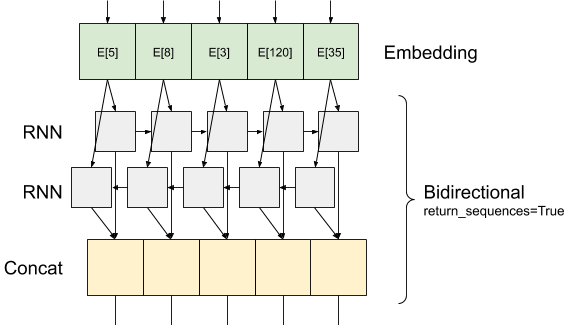

In [19]:
model = tf.keras.Sequential([
    encoder,
    tf.keras.layers.Embedding(len(encoder.get_vocabulary()), 64, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64,  return_sequences=True)),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1)
])

In [20]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
              optimizer=tf.keras.optimizers.Adam(1e-4),
              metrics=['accuracy'])

In [21]:
history = model.fit(train_dataset, epochs=10,
                    validation_data=test_dataset,
                    validation_steps=30)

Epoch 1/10
391/391 [==============================] - 555s 1s/step - loss: 0.5993 - accuracy: 0.6136 - val_loss: 0.4087 - val_accuracy: 0.8266
Epoch 2/10
391/391 [==============================] - 516s 1s/step - loss: 0.3893 - accuracy: 0.8314 - val_loss: 0.3538 - val_accuracy: 0.8417
Epoch 3/10
391/391 [==============================] - 499s 1s/step - loss: 0.3390 - accuracy: 0.8545 - val_loss: 0.3340 - val_accuracy: 0.8500
Epoch 4/10
391/391 [==============================] - 507s 1s/step - loss: 0.3232 - accuracy: 0.8620 - val_loss: 0.3280 - val_accuracy: 0.8547
Epoch 5/10
391/391 [==============================] - 494s 1s/step - loss: 0.3123 - accuracy: 0.8664 - val_loss: 0.3297 - val_accuracy: 0.8583
Epoch 6/10
391/391 [==============================] - 492s 1s/step - loss: 0.3093 - accuracy: 0.8659 - val_loss: 0.3208 - val_accuracy: 0.8516
Epoch 7/10
391/391 [==============================] - 497s 1s/step - loss: 0.3024 - accuracy: 0.8702 - val_loss: 0.3264 - val_accuracy: 0.8516

In [22]:
test_loss, test_acc = model.evaluate(test_dataset)

print('Test Loss:', test_loss)
print('Test Accuracy:', test_acc)

391/391 [==============================] - 129s 330ms/step - loss: 0.3154 - accuracy: 0.8530
Test Loss: 0.3154136836528778
Test Accuracy: 0.8529599905014038


In [23]:
# predict on a sample text without padding.

sample_text = ('The movie was not good. The animation and the graphics '
               'were terrible. I would not recommend this movie.')
predictions = model.predict(np.array([sample_text]))
print(predictions)

1/1 [==============================] - 6s 6s/step
[[-1.6205835]]


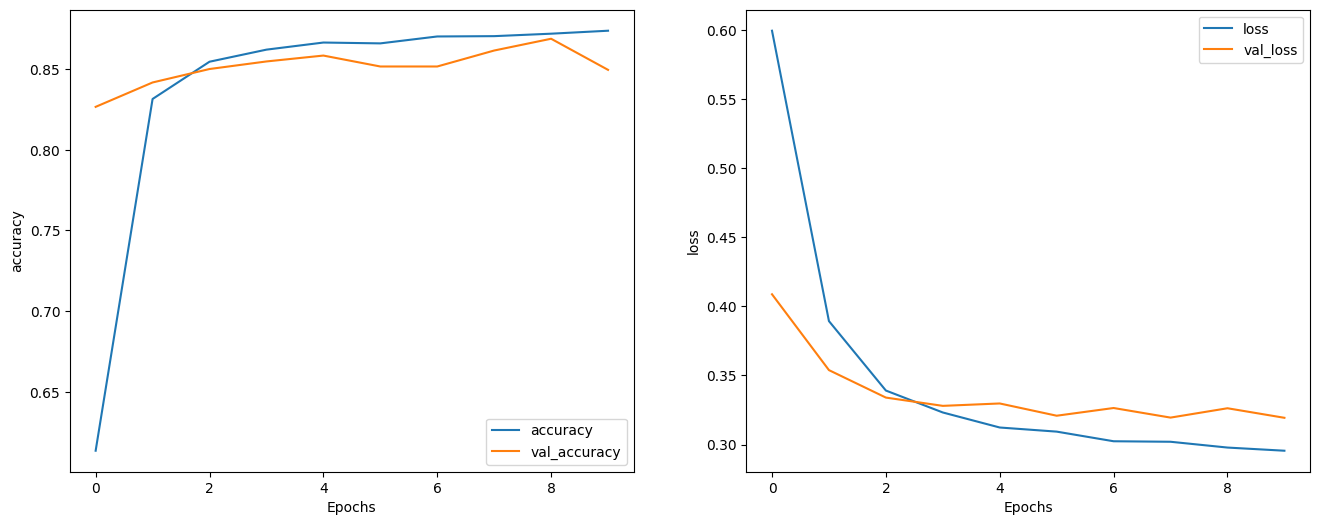

In [24]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')

# Fim

Esse notebook apresentou um exemplo de uso de uma Rede Neural Recorrente para classificação de texto. Você aprendeu a usar as bibliotecas de Redes Neurais Recorrentes, configurar uma arquitetura usando camadas LSTM biderecionais, treinar um modelo de PLN para classificação de sentimentos, avaliar o modelo treinado e predizer novas sentenças de entrada.

-------------------------------------------